In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")

In [21]:
dfh = pd.read_csv("heart.csv")

In [22]:
dfh

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### NANs

In [23]:
dfh.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Error Detection

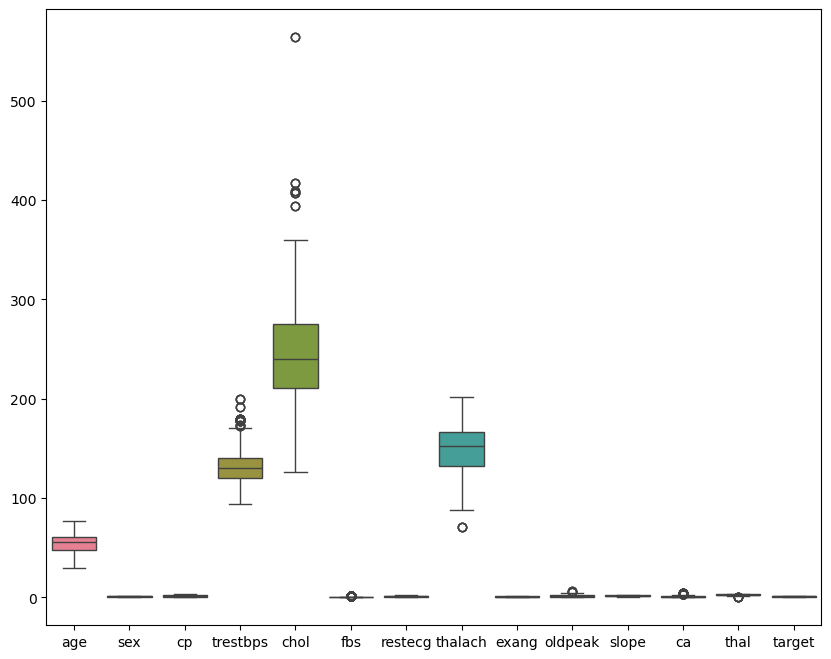

In [24]:
plt.figure(figsize=(10,8))
sns.boxplot(dfh)
plt.show()

In [25]:
dfh.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [26]:
cols = ['trestbps', 'chol', 'fbs',  'thalach',
       'oldpeak',  'ca', 'thal']

In [27]:
for i in cols:
    q1 = dfh[i].quantile(0.25)
    q3 = dfh[i].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1-(1.5*iqr)
    upper_limit = q3+(1.5*iqr)
    dfh[i] = dfh[i].map(lambda x:lower_limit if x<lower_limit else upper_limit if x>upper_limit else x)

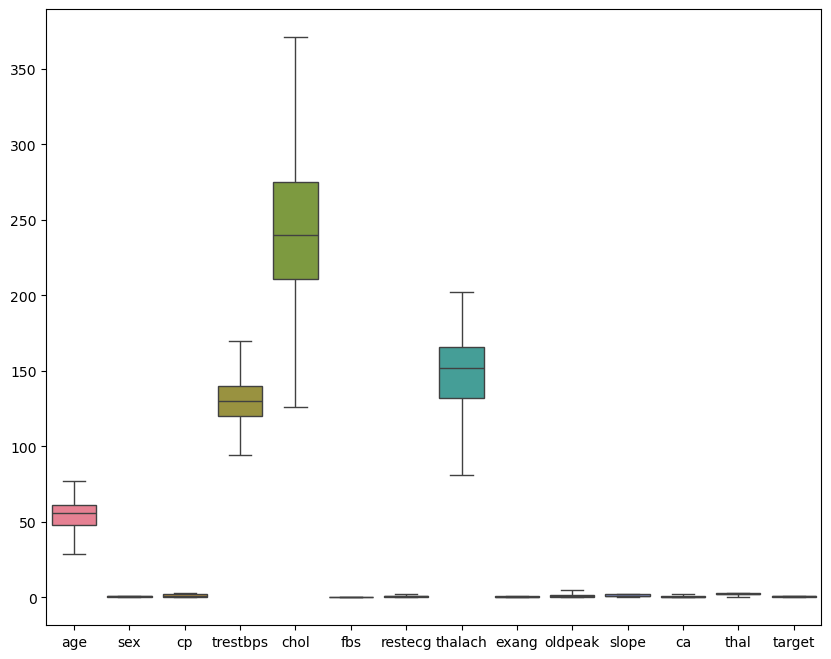

In [28]:
plt.figure(figsize=(10,8))
sns.boxplot(dfh)
plt.show()

### Data Seperation

In [29]:
X = dfh.drop("target",axis =1)

In [30]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125.0,212.0,0.0,1,168.0,0,1.0,2,2.0,3.0
1,53,1,0,140.0,203.0,0.0,0,155.0,1,3.1,0,0.0,3.0
2,70,1,0,145.0,174.0,0.0,1,125.0,1,2.6,0,0.0,3.0
3,61,1,0,148.0,203.0,0.0,1,161.0,0,0.0,2,1.0,3.0
4,62,0,0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221.0,0.0,1,164.0,1,0.0,2,0.0,2.0
1021,60,1,0,125.0,258.0,0.0,0,141.0,1,2.8,1,1.0,3.0
1022,47,1,0,110.0,275.0,0.0,0,118.0,1,1.0,1,1.0,2.0
1023,50,0,0,110.0,254.0,0.0,0,159.0,0,0.0,2,0.0,2.0


In [31]:
y = dfh["target"]

In [32]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

### Imbalance

In [33]:
y.value_counts()

target
1    526
0    499
Name: count, dtype: int64

<Axes: xlabel='target'>

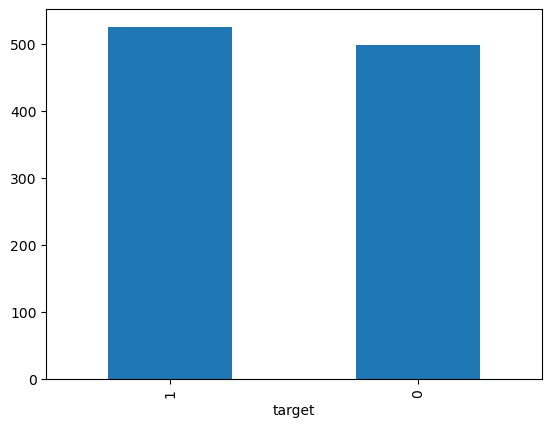

In [35]:
y.value_counts().plot(kind="bar")

### Data Splitting

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.20,random_state =930)

In [38]:
X.shape

(1025, 13)

In [39]:
X_train.shape

(820, 13)

In [40]:
X_test.shape

(205, 13)

In [41]:
y.shape

(1025,)

In [42]:
y_train.shape

(820,)

In [43]:
y_test.shape

(205,)

### Model Building

In [47]:
knn = KNeighborsClassifier()

In [48]:
knn

KNeighborsClassifier()

In [55]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [56]:
knn.score(X_test,y_test)

0.8439024390243902

### Auto RandomState

In [53]:
sc_list = []
for i in range(1000):
    X_train1,X_test1,y_train1,y_test1 = train_test_split(X,y,test_size =0.20,random_state =i)
    knn1 = KNeighborsClassifier()
    knn1.fit(X_train1,y_train1)
    sc = knn1.score(X_test1,y_test1)
    sc_list.append(sc)
m = max(sc_list)
ind = sc_list.index(m)
print(ind ,"==>" , m)

930 ==> 0.8439024390243902


### Auto ML

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [60]:
dec = DecisionTreeClassifier()
knn2 = KNeighborsClassifier()
rfc = RandomForestClassifier()
grb = GradientBoostingClassifier()
adb = AdaBoostClassifier()
sv = SVC()
log = LogisticRegression()

In [61]:
models =[dec,knn2,rfc,grb,adb,sv,log]

In [64]:
for m in models:
    m.fit(X_train,y_train)
    sc1 = m.score(X_test,y_test)
    print(m,"==>",sc1)

DecisionTreeClassifier() ==> 0.9853658536585366
KNeighborsClassifier() ==> 0.8439024390243902
RandomForestClassifier() ==> 1.0
GradientBoostingClassifier() ==> 0.9853658536585366
AdaBoostClassifier() ==> 0.9170731707317074
SVC() ==> 0.7365853658536585
LogisticRegression() ==> 0.8829268292682927
